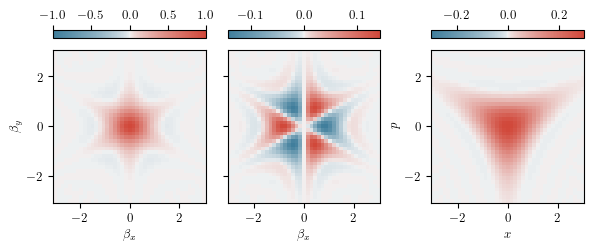

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graph_style as gs
from matplotlib.colors import LinearSegmentedColormap
gs.set_graph_style(1)

data = np.load("heatmaps.npz")

A = data["A"]
B = data["B"]
C = data["C"]
x = data["x"]
y = data["y"]

base_cmap = sns.diverging_palette(230, 15, as_cmap=True)

x_map = np.linspace(0, 1, 256)

# Accelerate movement away from white
gamma = 0.7

x_remap = 0.5 + 0.5 * np.sign(x_map - 0.5) * (2 * np.abs(x_map - 0.5))**gamma

cmap = LinearSegmentedColormap.from_list(
    "enhanced_diverging",
    base_cmap(x_remap)
)


fig_width = gs.get_fig_width()
fig_height = fig_width /2

fig, axs = plt.subplots(
    1, 3,
    figsize=(fig_width, fig_height),
    constrained_layout=True
)

for ax, Z, title, num in zip(
    axs,
    [A, B, C],
    ["(a)", "(b)", "(c)"],
    [1, 2, 3]

):
    ax.set_aspect("equal")
    ax.grid(False)
    Z = np.real(Z)  # Ensure Z is real for plotting
    im = ax.pcolormesh(
        x, y, Z,
        cmap=cmap,
        shading="auto",
        vmin=-np.max(np.abs(Z)), vmax=np.max(np.abs(Z)),
        rasterized=True
    )

    # Separate colorbar for this heatmap
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-2, 0, 2])
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.05,
        fraction=0.05,
        location="top",
    )

    if num in [1,2]:
        ax.set_xlabel(r"$\beta_x$")
    else:
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$p$")
    if ax == axs[1]:
        ax.tick_params(axis="y", labelleft=False)

axs[0].set_ylabel(r"$\beta_y$")

f_name = "..\\..\\pdf_figure\\ch6\\tomo_plot.pdf"
plt.savefig(f_name, bbox_inches="tight", pad_inches=0.05)